In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
results_path = "../results/evaluation_results.csv"

df = pd.read_csv(results_path)

print("Evaluation results loaded successfully.")
print("Number of test cases:", len(df))

df.head()

Evaluation results loaded successfully.
Number of test cases: 4


,test_id,category,difficulty,expected_decision,actual_decision,expected_matched_skills,actual_matched_skills,expected_missing_skills,actual_missing_skills,expected_experience_match,actual_experience_match,expected_education_match,actual_education_match,reason,latency_seconds
0,TC001,Normal Matching,Easy,Suitable,Suitable,Python;SQL;Excel;Power BI,Python;SQL;Excel;Power BI,NaN,NaN,True,unknown,True,true,The candidate explicitly possesses all require...,87.92
1,TC002,Normal Matching,Easy,Suitable,Suitable,Python;SQL;Power BI,Python;SQL;Power BI,NaN,NaN,True,unknown,True,true,The candidate explicitly possesses all require...,12.31
2,TC003,Normal Matching,Easy,Suitable,Suitable,Excel;SQL;Power BI;requirements analysis,Excel;SQL;Power BI;requirements analysis,NaN,NaN,True,true,True,unknown,The candidate explicitly possesses all require...,45.41
3,TC004,Normal Matching,Easy,Suitable,Suitable,Java;Spring Boot;REST APIs;Git,Java;Spring Boot;REST APIs;Git,NaN,NaN,True,unknown,True,true,The candidate explicitly possesses all require...,10.62


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(4, 15)

Columns:
['test_id', 'category', 'difficulty', 'expected_decision', 'actual_decision', 'expected_matched_skills', 'actual_matched_skills', 'expected_missing_skills', 'actual_missing_skills', 'expected_experience_match', 'actual_experience_match', 'expected_education_match', 'actual_education_match', 'reason', 'latency_seconds']

Missing Values:
test_id                      0
category                     0
difficulty                   0
expected_decision            0
actual_decision              0
expected_matched_skills      0
actual_matched_skills        0
expected_missing_skills      4
actual_missing_skills        4
expected_experience_match    0
actual_experience_match      0
expected_education_match     0
actual_education_match       0
reason                       0
latency_seconds              0
dtype: int64


In [4]:
comparison = df[
    [
        "test_id",
        "category",
        "expected_decision",
        "actual_decision"
    ]
].copy()

comparison["correct"] = (
    comparison["expected_decision"]
    == comparison["actual_decision"]
)

comparison.head(10)

,test_id,category,expected_decision,actual_decision,correct
0,TC001,Normal Matching,Suitable,Suitable,True
1,TC002,Normal Matching,Suitable,Suitable,True
2,TC003,Normal Matching,Suitable,Suitable,True
3,TC004,Normal Matching,Suitable,Suitable,True


In [5]:
accuracy = accuracy_score(
    df["expected_decision"],
    df["actual_decision"]
)

print(f"Overall Accuracy: {accuracy:.2%}")

Overall Accuracy: 100.00%


In [7]:
precision = precision_score(
    df["expected_decision"],
    df["actual_decision"],
    average="weighted",
    zero_division=0
)

recall = recall_score(
    df["expected_decision"],
    df["actual_decision"],
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    df["expected_decision"],
    df["actual_decision"],
    average="weighted",
    zero_division=0
)

print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1 Score:  {f1:.2%}")

Precision: 100.00%
Recall:    100.00%
F1 Score:  100.00%


In [8]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics["Score"] = metrics["Score"].round(4)

metrics

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0


In [9]:
labels = [
    "Suitable",
    "Not Suitable",
    "Review"
]

cm = confusion_matrix(
    df["expected_decision"],
    df["actual_decision"],
    labels=labels
)

print(cm)

[[4 0 0]
 [0 0 0]
 [0 0 0]]


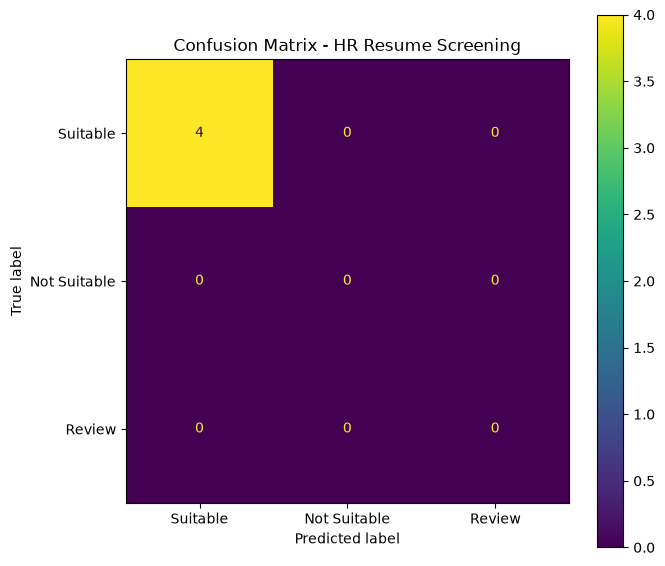

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax)

plt.title("Confusion Matrix - HR Resume Screening")

plt.tight_layout()

plt.show()

In [11]:
df["correct"] = (
    df["expected_decision"]
    == df["actual_decision"]
)

category_accuracy = (
    df.groupby("category")["correct"]
    .mean()
    .sort_values(ascending=False)
)

category_accuracy

category
Normal Matching    1.0
Name: correct, dtype: float64

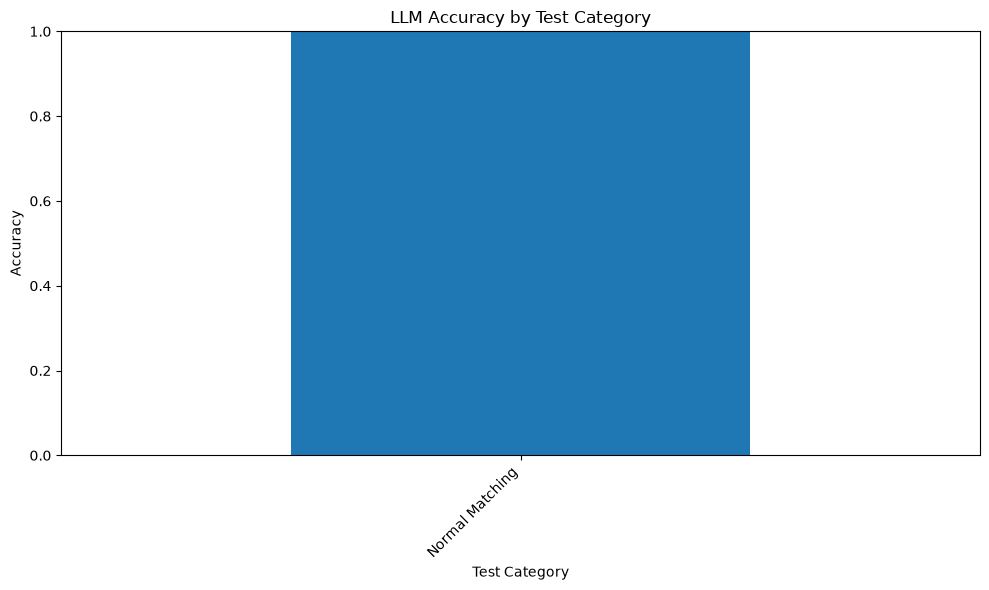

In [12]:
plt.figure(figsize=(10, 6))

category_accuracy.plot(
    kind="bar"
)

plt.title("LLM Accuracy by Test Category")

plt.xlabel("Test Category")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [13]:
decision_counts = df["actual_decision"].value_counts()

decision_counts

actual_decision
Suitable    4
Name: count, dtype: int64

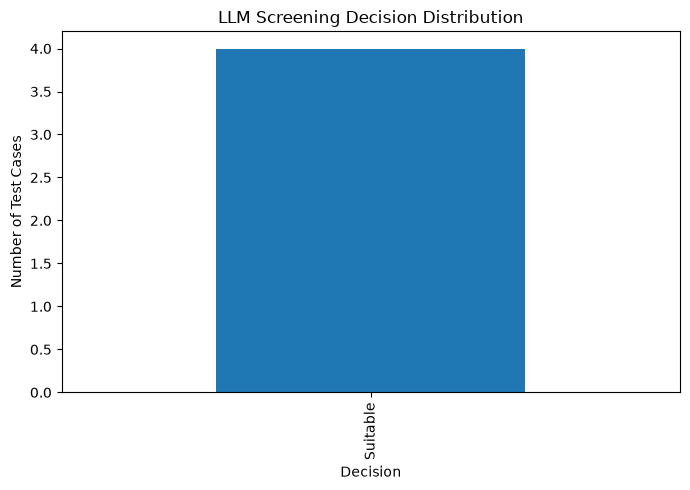

In [14]:
plt.figure(figsize=(7, 5))

decision_counts.plot(
    kind="bar"
)

plt.title("LLM Screening Decision Distribution")

plt.xlabel("Decision")

plt.ylabel("Number of Test Cases")

plt.tight_layout()

plt.show()

In [15]:
correct_count = df["correct"].sum()
incorrect_count = len(df) - correct_count

print("Correct predictions:", correct_count)
print("Incorrect predictions:", incorrect_count)

accuracy_summary = pd.DataFrame({
    "Result": ["Correct", "Incorrect"],
    "Count": [correct_count, incorrect_count]
})

accuracy_summary

Correct predictions: 4
Incorrect predictions: 0


,Result,Count
0,Correct,4
1,Incorrect,0


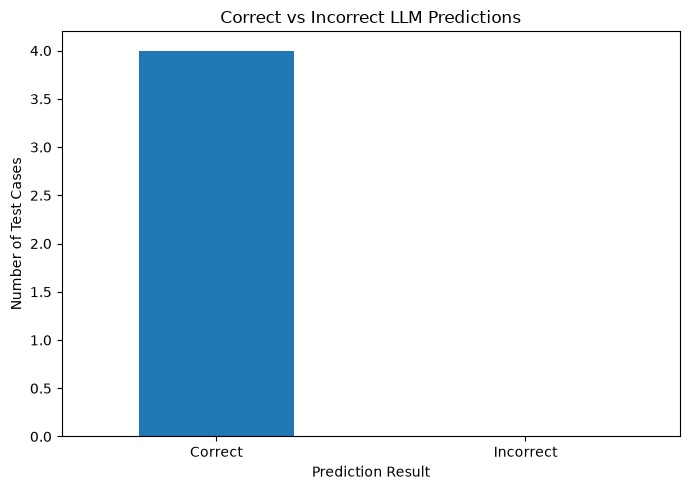

In [16]:
plt.figure(figsize=(7, 5))

accuracy_summary.set_index("Result")["Count"].plot(
    kind="bar"
)

plt.title("Correct vs Incorrect LLM Predictions")

plt.xlabel("Prediction Result")

plt.ylabel("Number of Test Cases")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [17]:
failed_cases = df[
    df["expected_decision"]
    != df["actual_decision"]
][
    [
        "test_id",
        "category",
        "expected_decision",
        "actual_decision",
        "reason"
    ]
]

print("Number of failed test cases:", len(failed_cases))

failed_cases

Number of failed test cases: 0


,test_id,category,expected_decision,actual_decision,reason


In [18]:
failure_by_category = (
    failed_cases["category"]
    .value_counts()
)

failure_by_category

Series([], Name: count, dtype: int64)

IndexError: index 0 is out of bounds for axis 0 with size 0

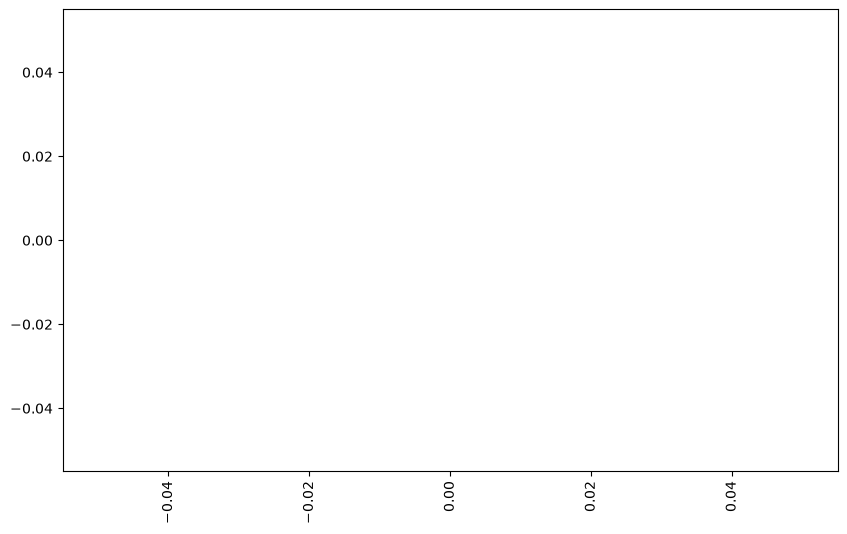

In [19]:
plt.figure(figsize=(10, 6))

failure_by_category.plot(
    kind="bar"
)

plt.title("Failure Count by Test Category")

plt.xlabel("Category")

plt.ylabel("Number of Failures")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [20]:
print(
    "Average response time:",
    df["latency_seconds"].mean()
)

print(
    "Minimum response time:",
    df["latency_seconds"].min()
)

print(
    "Maximum response time:",
    df["latency_seconds"].max()
)

Average response time: 39.065
Minimum response time: 10.62
Maximum response time: 87.92


In [21]:
latency_summary = pd.DataFrame({
    "Metric": [
        "Average Latency",
        "Minimum Latency",
        "Maximum Latency"
    ],
    "Seconds": [
        df["latency_seconds"].mean(),
        df["latency_seconds"].min(),
        df["latency_seconds"].max()
    ]
})

latency_summary

,Metric,Seconds
0,Average Latency,39.065
1,Minimum Latency,10.620
2,Maximum Latency,87.920


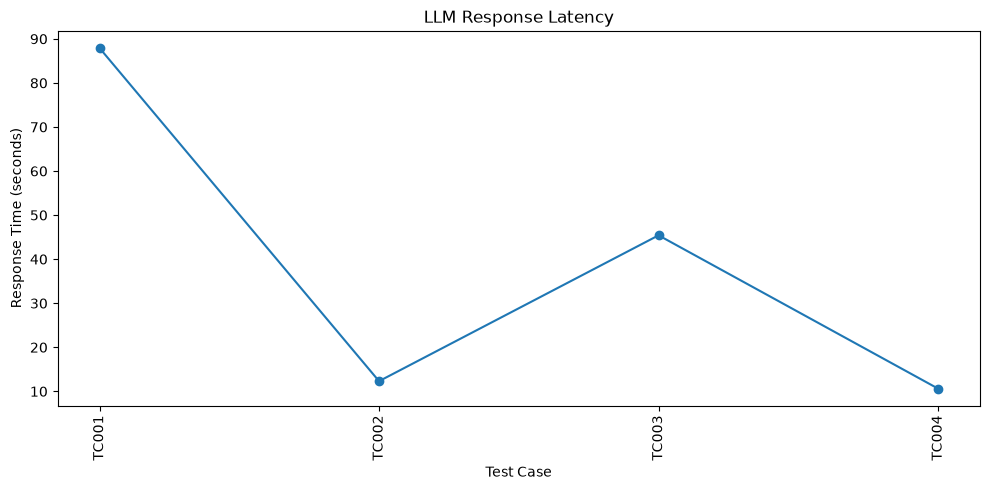

Analysis results saved successfully.
FINAL LLM EVALUATION SUMMARY
Total Test Cases : 4
Accuracy         : 100.00%
Precision        : 100.00%
Recall           : 100.00%
F1 Score         : 100.00%
Correct Cases    : 4
Failed Cases     : 0
Average Latency  : 39.06 seconds


In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["test_id"],
    df["latency_seconds"],
    marker="o"
)

plt.title("LLM Response Latency")

plt.xlabel("Test Case")

plt.ylabel("Response Time (seconds)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


category_performance = (
    df.groupby("category")
    .agg(
        total_tests=("test_id", "count"),
        correct=("correct", "sum"),
        average_latency=("latency_seconds", "mean")
    )
)

category_performance["accuracy"] = (
    category_performance["correct"]
    / category_performance["total_tests"]
)


metrics.to_csv(
    "../results/summary_metrics.csv",
    index=False
)

category_performance.to_csv(
    "../results/category_performance.csv"
)

failed_cases.to_csv(
    "../results/failed_cases.csv",
    index=False
)

print("Analysis results saved successfully.")


print("=" * 50)
print("FINAL LLM EVALUATION SUMMARY")
print("=" * 50)

print(f"Total Test Cases : {len(df)}")
print(f"Accuracy         : {accuracy:.2%}")
print(f"Precision        : {precision:.2%}")
print(f"Recall           : {recall:.2%}")
print(f"F1 Score         : {f1:.2%}")
print(f"Correct Cases    : {correct_count}")
print(f"Failed Cases     : {incorrect_count}")
print(
    f"Average Latency  : "
    f"{df['latency_seconds'].mean():.2f} seconds"
)

print("=" * 50)

